# `^{171}\mathrm{Yb}` UV Rabi-frequency noise response of time-optimal phase pulses

本 notebook 是 notebook-first 开发记录。目标是在 `^{171}\mathrm{Yb}` UV Rydberg 门语境下，
对比 Gaussian 上升/下降沿和 7 阶多项式上升/下降沿的 phase-only time-optimal 控制脉冲，
然后固定各自脉冲扫描拉比频率乘性误差 `\Omega(t) \rightarrow (1+\epsilon)\Omega(t)` 对 gate fidelity 的影响。


## 模型和近似

- Hilbert space: reduced basis `|00>, |0c>, |0r>, |cc>, |W_cr>, |rr>`。
- Computational scoring: 读取 `|00>`, `|0c>/<c0>`, `|cc>` 三个对角振幅，权重为 `1, 2, 1`。
- Blockade: 默认 `B/2\pi = 160 MHz`，UV peak drive 默认 `\Omega_{\max}/2\pi = 10 MHz`。
- Decay-only baseline: Rydberg lifetime `65 us`，用 no-jump 非厄米项表示。
- Rabi noise response: quasistatic fractional amplitude error `\epsilon \in [-0.05, 0.05]`。
- Edge envelopes: 当前 Gaussian edge 与一个 7 阶 polynomial smoothstep edge 并列比较。

我没有在本环境中成功解析 arXiv:2604.12279v1 的 B1/B2 公式；因此这里显式使用
`B2(s)=35s^4-84s^5+70s^6-20s^7`，并把 fall edge 写为其 time reverse `B1`。


In [1]:
from __future__ import annotations

import csv
import json
import math
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.linalg import expm, expm_frechet
from scipy.optimize import OptimizeResult, minimize


def wrap_phase(phases: np.ndarray | list[float]) -> np.ndarray:
    """Wrap phase variables to (-pi, pi] so optimizer steps remain numerically stable."""
    values = np.asarray(phases, dtype=np.float64)
    return (values + np.pi) % (2.0 * np.pi) - np.pi


def unwrap_for_plot(phases: np.ndarray | list[float]) -> np.ndarray:
    """Unwrap optimized phase controls only for plotting; propagation still uses wrapped phases."""
    return np.unwrap(np.asarray(phases, dtype=np.float64))


def gaussian_edge_envelope(num_tslots: int, total_time_ns: float, edge_time_ns: float, sigma_to_edge: float = 1.0 / 3.0) -> np.ndarray:
    """Return the present Gaussian rise/fall envelope used for the UV Rydberg pulse."""
    centers = (np.arange(num_tslots, dtype=np.float64) + 0.5) * float(total_time_ns) / float(num_tslots)
    envelope = np.ones(num_tslots, dtype=np.float64)
    edge = float(edge_time_ns)
    if edge <= 0.0:
        return envelope
    sigma = max(edge * float(sigma_to_edge), 1e-12)
    rise = centers < edge
    fall = centers > float(total_time_ns) - edge
    envelope[rise] = np.exp(-0.5 * ((centers[rise] - edge) / sigma) ** 2)
    envelope[fall] = np.exp(-0.5 * ((centers[fall] - (float(total_time_ns) - edge)) / sigma) ** 2)
    return np.clip(envelope, 0.0, 1.0)


def b2_seventh_order_smoothstep(s: np.ndarray | float) -> np.ndarray:
    """Seventh-order B2 smoothstep used as the polynomial rise profile.

    The polynomial is B2(s)=35s^4-84s^5+70s^6-20s^7 for s in [0, 1].
    It is C3-smooth at both endpoints.  I use this explicit smoothstep form
    because the arXiv v1 formula could not be programmatically verified here;
    if the paper's B1/B2 coefficients differ, this cell is the replacement point.
    """
    x = np.clip(np.asarray(s, dtype=np.float64), 0.0, 1.0)
    return 35.0 * x**4 - 84.0 * x**5 + 70.0 * x**6 - 20.0 * x**7


def b1_seventh_order_fall(s: np.ndarray | float) -> np.ndarray:
    """Seventh-order B1 fall profile written as the time reverse of B2."""
    x = np.clip(np.asarray(s, dtype=np.float64), 0.0, 1.0)
    return 1.0 - b2_seventh_order_smoothstep(x)


def polynomial_edge_envelope(num_tslots: int, total_time_ns: float, edge_time_ns: float) -> np.ndarray:
    """Return a seventh-order polynomial rise/fall envelope using B2 rise and B1 fall."""
    centers = (np.arange(num_tslots, dtype=np.float64) + 0.5) * float(total_time_ns) / float(num_tslots)
    envelope = np.ones(num_tslots, dtype=np.float64)
    edge = float(edge_time_ns)
    if edge <= 0.0:
        return envelope
    rise = centers < edge
    fall = centers > float(total_time_ns) - edge
    envelope[rise] = b2_seventh_order_smoothstep(centers[rise] / edge)
    envelope[fall] = b1_seventh_order_fall((centers[fall] - (float(total_time_ns) - edge)) / edge)
    return np.clip(envelope, 0.0, 1.0)


def phase_regularization(phases: np.ndarray, smoothness_weight: float, curvature_weight: float) -> tuple[float, np.ndarray]:
    """Penalize sharp phase jumps while respecting the periodic phase variable."""
    phases = np.asarray(phases, dtype=np.float64)
    cost = 0.0
    gradient = np.zeros_like(phases)
    if phases.size >= 2 and smoothness_weight > 0.0:
        delta = wrap_phase(phases[1:] - phases[:-1])
        cost += smoothness_weight * float(np.sum(delta**2))
        gradient[:-1] -= 2.0 * smoothness_weight * delta
        gradient[1:] += 2.0 * smoothness_weight * delta
    if phases.size >= 3 and curvature_weight > 0.0:
        delta = wrap_phase(phases[1:] - phases[:-1])
        curvature = wrap_phase(delta[1:] - delta[:-1])
        cost += curvature_weight * float(np.sum(curvature**2))
        gradient[:-2] += 2.0 * curvature_weight * curvature
        gradient[1:-1] -= 4.0 * curvature_weight * curvature
        gradient[2:] += 2.0 * curvature_weight * curvature
    return cost, gradient


@dataclass(frozen=True)
class UVRabiNoiseConfig:
    """Minimal configuration for the notebook-only UV Rydberg phase model."""

    omega_max_mhz: float = 10.0
    blockade_shift_mhz: float = 160.0
    edge_time_ns: float = 40.0
    edge_kind: str = "gaussian"
    num_tslots: int = 48
    rydberg_lifetime_s: float = 65e-6
    smoothness_weight: float = 1e-4
    curvature_weight: float = 1e-4
    max_iter: int = 110
    target_threshold: float = 0.999


class UVPhaseModel:
    """Self-contained 6D shelved-control/Rydberg phase model for this notebook.

    Basis order: |00>, |0c>, |0r>, |cc>, |W_cr>, |rr>.  The computational
    scoring uses the diagonal amplitudes of |00>, |0c>/<c0>, and |cc>, with
    weights 1, 2, and 1 to reconstruct the four logical basis states.
    """

    computational_indices = np.array([0, 1, 3], dtype=np.int64)
    weights = np.array([1.0, 2.0, 1.0], dtype=np.float64)
    alpha_coefficients = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    beta_coefficients = np.array([0.0, 1.0, 2.0], dtype=np.float64)

    def __init__(self, config: UVRabiNoiseConfig, total_time_ns: float) -> None:
        """Build dimensionless generators for one total pulse duration."""
        self.config = config
        self.total_time_ns = float(total_time_ns)
        self.num_tslots = int(config.num_tslots)
        self.evo_time = 2.0 * np.pi * config.omega_max_mhz * 1e6 * self.total_time_ns * 1e-9
        self.dt = self.evo_time / self.num_tslots
        if config.edge_kind == "gaussian":
            self.envelope = gaussian_edge_envelope(self.num_tslots, self.total_time_ns, config.edge_time_ns)
        elif config.edge_kind == "polynomial_b2":
            self.envelope = polynomial_edge_envelope(self.num_tslots, self.total_time_ns, config.edge_time_ns)
        else:
            raise ValueError(f"Unknown edge_kind: {config.edge_kind}")

        self.h_d = np.zeros((6, 6), dtype=np.complex128)
        self.h_x = np.zeros_like(self.h_d)
        self.h_y = np.zeros_like(self.h_d)
        self.h_d[5, 5] = config.blockade_shift_mhz / config.omega_max_mhz
        self._add_quadrature_coupling(1, 2, 0.5)
        self._add_quadrature_coupling(3, 4, 1.0 / np.sqrt(2.0))
        self._add_quadrature_coupling(4, 5, 1.0 / np.sqrt(2.0))

        decay_rate_over_omega = 1.0 / (2.0 * np.pi * config.omega_max_mhz * 1e6 * config.rydberg_lifetime_s)
        rydberg_count = np.array([0.0, 0.0, 1.0, 0.0, 1.0, 2.0], dtype=np.float64)
        self.g_d = -1j * self.h_d - 0.5 * np.diag(rydberg_count * decay_rate_over_omega).astype(np.complex128)
        self.g_x = -1j * self.h_x
        self.g_y = -1j * self.h_y

    def _add_quadrature_coupling(self, left: int, right: int, strength: float) -> None:
        """Add x/y quadrature matrix elements for a resonant Rydberg coupling."""
        self.h_x[left, right] = strength
        self.h_x[right, left] = strength
        self.h_y[left, right] = -1j * strength
        self.h_y[right, left] = 1j * strength

    def initial_guess(self, seed: int) -> np.ndarray:
        """Generate a smooth-ish random phase seed plus free logical phases alpha and beta."""
        rng = np.random.default_rng(seed)
        grid = np.linspace(0.0, np.pi, self.num_tslots, endpoint=False, dtype=np.float64)
        phases = 0.6 * np.sin(2.0 * grid + rng.uniform(0.0, 2.0 * np.pi))
        phases += 0.2 * rng.normal(size=self.num_tslots)
        return np.concatenate([wrap_phase(phases), np.array([0.0, 0.0], dtype=np.float64)])

    def target_phases(self, alpha: float, beta: float) -> np.ndarray:
        """Return the diagonal target family diag(e^ia, e^i(a+b), -e^i(a+2b))."""
        return np.array([np.exp(1j * alpha), np.exp(1j * (alpha + beta)), -np.exp(1j * (alpha + 2.0 * beta))], dtype=np.complex128)

    def generator(self, amplitude: float, phase: float, amplitude_scale: float = 1.0) -> np.ndarray:
        """Return the dimensionless non-Hermitian generator for one time slot."""
        scaled = float(amplitude_scale) * float(amplitude)
        return self.g_d + scaled * (math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y)

    def propagate(self, phases: np.ndarray, amplitude_scale: float = 1.0) -> np.ndarray:
        """Propagate the no-jump Kraus operator through all phase-control slots."""
        unitary = np.eye(6, dtype=np.complex128)
        for amplitude, phase in zip(self.envelope, wrap_phase(phases)):
            unitary = expm(self.dt * self.generator(float(amplitude), float(phase), amplitude_scale)) @ unitary
        return unitary

    def metrics(self, phases: np.ndarray, alpha: float, beta: float, amplitude_scale: float = 1.0) -> dict[str, float | list[complex]]:
        """Compute process fidelity, no-jump average fidelity, and loss proxy for a pulse."""
        kraus = self.propagate(phases, amplitude_scale=amplitude_scale)
        z_diag = np.diag(kraus)[self.computational_indices]
        target = self.target_phases(alpha, beta)
        overlap = np.sum(self.weights * np.conj(target) * z_diag)
        process_fidelity = float(abs(overlap) ** 2 / 16.0)
        active_population = float(np.sum(self.weights * np.abs(z_diag) ** 2) / 4.0)
        average_fidelity = float((4.0 * process_fidelity + active_population) / 5.0)
        phase_error = float(wrap_phase([np.angle(z_diag[2]) - 2.0 * np.angle(z_diag[1]) + np.angle(z_diag[0]) - np.pi])[0])
        return {
            "process_fidelity": process_fidelity,
            "no_jump_average_fidelity": average_fidelity,
            "active_population": active_population,
            "loss_proxy": 1.0 - active_population,
            "cz_phase_error_rad": phase_error,
            "z_diag": [complex(value) for value in z_diag],
        }

    def objective_and_gradient(self, variables: np.ndarray) -> tuple[float, np.ndarray]:
        """Return the L-BFGS-B objective and analytic phase gradient for nominal Omega."""
        phases = wrap_phase(variables[: self.num_tslots])
        alpha = float(variables[-2])
        beta = float(variables[-1])
        propagators: list[np.ndarray] = []
        prefixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128)]
        current = prefixes[0]
        for amplitude, phase in zip(self.envelope, phases):
            generator = self.generator(float(amplitude), float(phase), amplitude_scale=1.0)
            propagator = expm(self.dt * generator)
            propagators.append(propagator)
            current = propagator @ current
            prefixes.append(current)
        z_diag = np.diag(current)[self.computational_indices]
        target = self.target_phases(alpha, beta)
        conjugate_target = np.conj(target)
        overlap = np.sum(self.weights * conjugate_target * z_diag)
        process_fidelity = abs(overlap) ** 2 / 16.0
        gradient = np.zeros_like(variables)
        suffixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128) for _ in range(self.num_tslots)]
        suffix = np.eye(6, dtype=np.complex128)
        for index in range(self.num_tslots - 1, -1, -1):
            suffixes[index] = suffix
            suffix = suffix @ propagators[index]
        for index, (amplitude, phase) in enumerate(zip(self.envelope, phases)):
            generator = self.generator(float(amplitude), float(phase), amplitude_scale=1.0)
            d_generator = float(amplitude) * (-math.sin(float(phase)) * self.g_x + math.cos(float(phase)) * self.g_y)
            d_propagator = expm_frechet(self.dt * generator, self.dt * d_generator, compute_expm=False)
            d_unitary = suffixes[index] @ d_propagator @ prefixes[index]
            dz_diag = np.diag(d_unitary)[self.computational_indices]
            d_overlap = np.sum(self.weights * conjugate_target * dz_diag)
            gradient[index] = -2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
        for offset, coefficients in enumerate([self.alpha_coefficients, self.beta_coefficients]):
            d_conjugate_target = -1j * coefficients * conjugate_target
            d_overlap = np.sum(self.weights * d_conjugate_target * z_diag)
            gradient[-2 + offset] = -2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
        regularization, regularization_gradient = phase_regularization(phases, self.config.smoothness_weight, self.config.curvature_weight)
        gradient[: self.num_tslots] += regularization_gradient
        return float(1.0 - process_fidelity + regularization), gradient

    def optimize(self, starts: list[np.ndarray]) -> tuple[OptimizeResult, dict[str, object]]:
        """Run several local L-BFGS-B starts and return the best process fidelity result."""
        bounds = [(-np.pi, np.pi)] * self.num_tslots + [(-np.pi, np.pi), (-np.pi, np.pi)]
        best_result: OptimizeResult | None = None
        best_eval: dict[str, object] | None = None
        for start in starts:
            result = minimize(
                self.objective_and_gradient,
                np.asarray(start, dtype=np.float64),
                jac=True,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": int(self.config.max_iter), "ftol": 1e-11, "maxls": 30},
            )
            phases = wrap_phase(result.x[: self.num_tslots])
            evaluated = self.metrics(phases, float(result.x[-2]), float(result.x[-1]), amplitude_scale=1.0)
            evaluated.update({"phases": phases, "alpha": float(result.x[-2]), "beta": float(result.x[-1])})
            if best_eval is None or float(evaluated["process_fidelity"]) > float(best_eval["process_fidelity"]):
                best_result = result
                best_eval = evaluated
        if best_result is None or best_eval is None:
            raise RuntimeError("No optimizer starts were supplied")
        return best_result, best_eval


def run_time_scan(config: UVRabiNoiseConfig, time_grid_ns: list[float], seed_offset: int = 0) -> tuple[list[dict[str, object]], dict[str, object], str]:
    """Optimize one edge kind over a short time grid and select a nominal decay-only pulse."""
    scan_rows: list[dict[str, object]] = []
    previous_variables = None
    for time_index, total_time_ns in enumerate(time_grid_ns):
        model = UVPhaseModel(config, total_time_ns=total_time_ns)
        starts = []
        if previous_variables is not None:
            starts.append(previous_variables.copy())
        starts.append(model.initial_guess(seed_offset + 71000 + time_index))
        starts.append(model.initial_guess(seed_offset + 93000 + time_index))
        result, evaluated = model.optimize(starts)
        previous_variables = np.asarray(result.x, dtype=np.float64).copy()
        row = {
            "edge_kind": config.edge_kind,
            "omega_max_mhz": config.omega_max_mhz,
            "blockade_shift_mhz": config.blockade_shift_mhz,
            "edge_time_ns": config.edge_time_ns,
            "total_time_ns": total_time_ns,
            "num_tslots": config.num_tslots,
            "process_fidelity": float(evaluated["process_fidelity"]),
            "no_jump_average_fidelity": float(evaluated["no_jump_average_fidelity"]),
            "active_population": float(evaluated["active_population"]),
            "loss_proxy": float(evaluated["loss_proxy"]),
            "cz_phase_error_rad": float(evaluated["cz_phase_error_rad"]),
            "optimizer_success": bool(result.success),
            "optimizer_iterations": int(result.nit),
            "alpha": float(evaluated["alpha"]),
            "beta": float(evaluated["beta"]),
            "phases": [float(value) for value in evaluated["phases"]],
        }
        scan_rows.append(row)
        print(
            f"{config.edge_kind:13s} T={total_time_ns:6.1f} ns  "
            f"F_process={row['process_fidelity']:.9f}  loss={row['loss_proxy']:.3e}  "
            f"success={row['optimizer_success']} nit={row['optimizer_iterations']}"
        )
    passing = [row for row in scan_rows if row["process_fidelity"] >= config.target_threshold]
    selected = passing[0] if passing else max(scan_rows, key=lambda row: row["process_fidelity"])
    selection_kind = "first above threshold" if passing else "best below threshold"
    return scan_rows, selected, selection_kind


def rabi_response_rows(config: UVRabiNoiseConfig, selected_row: dict[str, object], epsilon_values: np.ndarray) -> list[dict[str, float]]:
    """Evaluate fixed-pulse fidelity under Omega(t) -> (1 + epsilon) Omega(t)."""
    model = UVPhaseModel(config, total_time_ns=float(selected_row["total_time_ns"]))
    phases = np.asarray(selected_row["phases"], dtype=np.float64)
    alpha = float(selected_row["alpha"])
    beta = float(selected_row["beta"])
    baseline_fidelity = float(selected_row["process_fidelity"])
    rows: list[dict[str, float]] = []
    for epsilon in epsilon_values:
        metrics = model.metrics(phases, alpha, beta, amplitude_scale=1.0 + float(epsilon))
        process_fidelity = float(metrics["process_fidelity"])
        rows.append(
            {
                "edge_kind": config.edge_kind,
                "epsilon": float(epsilon),
                "amplitude_scale": float(1.0 + epsilon),
                "decay_only_baseline_fidelity": baseline_fidelity,
                "process_fidelity": process_fidelity,
                "delta_from_decay_only": process_fidelity - baseline_fidelity,
                "process_infidelity": 1.0 - process_fidelity,
                "no_jump_average_fidelity": float(metrics["no_jump_average_fidelity"]),
                "active_population": float(metrics["active_population"]),
                "loss_proxy": float(metrics["loss_proxy"]),
                "cz_phase_error_rad": float(metrics["cz_phase_error_rad"]),
            }
        )
    return rows


In [2]:
BASE_CONFIG = UVRabiNoiseConfig(
    omega_max_mhz=10.0,
    blockade_shift_mhz=160.0,
    edge_time_ns=40.0,
    edge_kind="gaussian",
    num_tslots=48,
    rydberg_lifetime_s=65e-6,
    smoothness_weight=1e-4,
    curvature_weight=1e-4,
    max_iter=110,
    target_threshold=0.999,
)
GAUSSIAN_CONFIG = BASE_CONFIG
POLYNOMIAL_CONFIG = replace(BASE_CONFIG, edge_kind="polynomial_b2")

TIME_GRID_NS = [140.0, 160.0, 180.0, 200.0]
EPSILON_VALUES = np.linspace(-0.05, 0.05, 101, dtype=np.float64)
ARTIFACT_DIR = Path("artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(BASE_CONFIG)
print(f"Time scan grid: {TIME_GRID_NS} ns")
print(f"Rabi fractional error scan: {EPSILON_VALUES[0]:+.3f} to {EPSILON_VALUES[-1]:+.3f} with {len(EPSILON_VALUES)} points")
print(f"Artifact directory: {ARTIFACT_DIR}")


UVRabiNoiseConfig(omega_max_mhz=10.0, blockade_shift_mhz=160.0, edge_time_ns=40.0, edge_kind='gaussian', num_tslots=48, rydberg_lifetime_s=6.5e-05, smoothness_weight=0.0001, curvature_weight=0.0001, max_iter=110, target_threshold=0.999)
Time scan grid: [140.0, 160.0, 180.0, 200.0] ns
Rabi fractional error scan: -0.050 to +0.050 with 101 points
Artifact directory: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603


## Gaussian edge 与 7 阶 polynomial edge

Gaussian edge 是当前项目已经使用的上升/下降沿。Polynomial edge 使用 7 阶 smoothstep，
端点处函数值和前三阶导数连续，便于后续替换为文献中严格的 B1/B2 参数化形式。


Saved envelope comparison plot: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/gaussian_vs_polynomial_edge_envelope.png


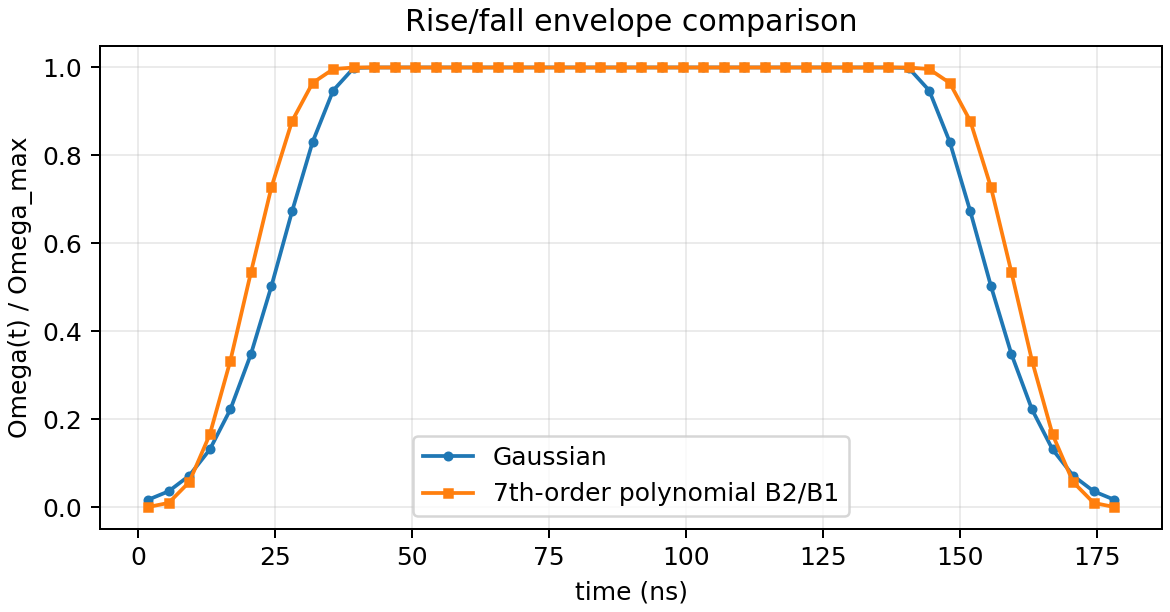

In [3]:
probe_time_ns = 180.0
gaussian_model = UVPhaseModel(GAUSSIAN_CONFIG, total_time_ns=probe_time_ns)
polynomial_model = UVPhaseModel(POLYNOMIAL_CONFIG, total_time_ns=probe_time_ns)
slot_times_ns = (np.arange(BASE_CONFIG.num_tslots) + 0.5) * probe_time_ns / BASE_CONFIG.num_tslots

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)
ax.plot(slot_times_ns, gaussian_model.envelope, marker="o", ms=3, lw=1.5, label="Gaussian")
ax.plot(slot_times_ns, polynomial_model.envelope, marker="s", ms=3, lw=1.5, label="7th-order polynomial B2/B1")
ax.set_xlabel("time (ns)")
ax.set_ylabel("Omega(t) / Omega_max")
ax.set_title("Rise/fall envelope comparison")
ax.grid(alpha=0.25)
ax.legend()
envelope_png = ARTIFACT_DIR / "gaussian_vs_polynomial_edge_envelope.png"
fig.savefig(envelope_png, dpi=180)
plt.close(fig)
print(f"Saved envelope comparison plot: {envelope_png}")


## Decay-only time scan

这里先不加入额外 Rabi-frequency error，只考虑 `65 us` Rydberg decay 的 no-jump baseline。
对每种 edge envelope 分别做 phase-only 优化，并用第一个超过阈值的点作为 nominal pulse；
如果没有超过阈值，则选择该小网格中的最高 fidelity 点。


gaussian      T= 140.0 ns  F_process=0.878435976  loss=1.090e-01  success=True nit=68
gaussian      T= 160.0 ns  F_process=0.987373915  loss=1.239e-02  success=True nit=91
gaussian      T= 180.0 ns  F_process=0.999224006  loss=7.759e-04  success=False nit=110
gaussian      T= 200.0 ns  F_process=0.999192107  loss=8.077e-04  success=False nit=110
Selected gaussian: T=180.0 ns (first above threshold), decay-only F_process=0.999224006
polynomial_b2 T= 140.0 ns  F_process=0.922711934  loss=7.362e-02  success=True nit=106
polynomial_b2 T= 160.0 ns  F_process=0.999117062  loss=8.817e-04  success=True nit=98
polynomial_b2 T= 180.0 ns  F_process=0.999208139  loss=7.918e-04  success=False nit=110
polynomial_b2 T= 200.0 ns  F_process=0.999175034  loss=8.248e-04  success=False nit=110
Selected polynomial_b2: T=160.0 ns (first above threshold), decay-only F_process=0.999117062
Saved scan JSON: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/time_scan_results.json
Saved scan CSV:  ar

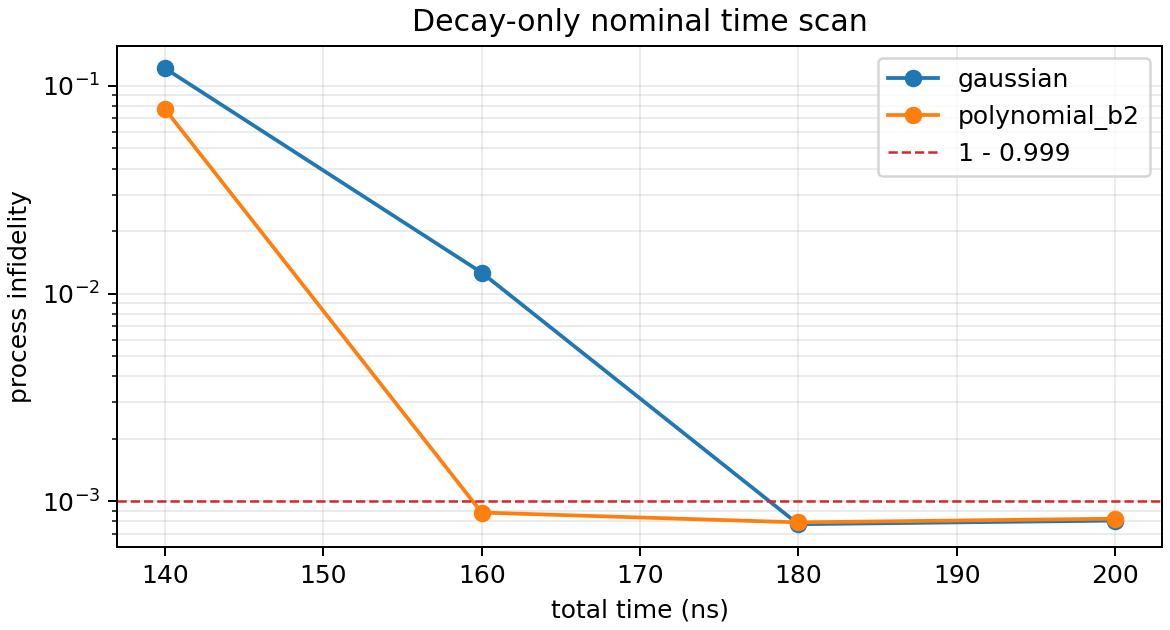

In [4]:
all_scan_rows = []
selected_by_edge = {}
selection_kind_by_edge = {}

for config, seed_offset in [(GAUSSIAN_CONFIG, 0), (POLYNOMIAL_CONFIG, 200000)]:
    rows, selected, selection_kind = run_time_scan(config, TIME_GRID_NS, seed_offset=seed_offset)
    all_scan_rows.extend(rows)
    selected_by_edge[config.edge_kind] = selected
    selection_kind_by_edge[config.edge_kind] = selection_kind
    print(
        f"Selected {config.edge_kind}: T={selected['total_time_ns']:.1f} ns "
        f"({selection_kind}), decay-only F_process={selected['process_fidelity']:.9f}"
    )

scan_json = ARTIFACT_DIR / "time_scan_results.json"
scan_csv = ARTIFACT_DIR / "time_scan_results.csv"
scan_json.write_text(
    json.dumps(
        {
            "config": BASE_CONFIG.__dict__,
            "time_grid_ns": TIME_GRID_NS,
            "selection_kind_by_edge": selection_kind_by_edge,
            "rows": all_scan_rows,
        },
        indent=2,
    ),
    encoding="utf-8",
)
with scan_csv.open("w", newline="", encoding="utf-8") as handle:
    columns = [key for key in all_scan_rows[0].keys() if key != "phases"]
    writer = csv.DictWriter(handle, fieldnames=columns)
    writer.writeheader()
    for row in all_scan_rows:
        writer.writerow({key: row[key] for key in columns})

fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
for edge_kind in ["gaussian", "polynomial_b2"]:
    group = [row for row in all_scan_rows if row["edge_kind"] == edge_kind]
    ax.plot([row["total_time_ns"] for row in group], [1.0 - row["process_fidelity"] for row in group], marker="o", lw=1.5, label=edge_kind)
ax.axhline(1.0 - BASE_CONFIG.target_threshold, color="tab:red", ls="--", lw=1.0, label=f"1 - {BASE_CONFIG.target_threshold}")
ax.set_yscale("log")
ax.set_xlabel("total time (ns)")
ax.set_ylabel("process infidelity")
ax.set_title("Decay-only nominal time scan")
ax.grid(alpha=0.25, which="both")
ax.legend()
time_scan_png = ARTIFACT_DIR / "time_scan_process_infidelity.png"
fig.savefig(time_scan_png, dpi=180)
plt.close(fig)
print(f"Saved scan JSON: {scan_json}")
print(f"Saved scan CSV:  {scan_csv}")
print(f"Saved scan plot: {time_scan_png}")


## 加入的拉比频率噪声是什么

这一格加入的不是新的 decay channel，而是一个 quasistatic multiplicative Rabi-frequency error：

`Omega(t) -> (1 + epsilon) Omega(t)`.

也就是说，优化得到的相位 `phi_k`、总时长、blockade 和 decay 都固定不变，只把所有 time slot
的 UV Rabi envelope 同时乘上 `1+\epsilon`。`epsilon=0` 就是上一节的 decay-only baseline；
`epsilon != 0` 衡量当前 optimal pulse 对全局振幅标定误差或慢漂移的敏感性。图中虚线给出
decay-only fidelity，插值曲线用于查看 fidelity 对 `epsilon` 的局部响应形状。


gaussian: epsilon=0 F=0.999224006; baseline=0.999224006; min F over scan=0.988301511
polynomial_b2: epsilon=0 F=0.999117062; baseline=0.999117062; min F over scan=0.986117000
Saved response JSON: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/rabi_fractional_error_response.json
Saved response CSV:  artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/rabi_fractional_error_response.csv
Saved response plot: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/rabi_fractional_error_response.png
Saved edge comparison plot: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/gaussian_vs_polynomial_rabi_response.png
Saved edge comparison JSON: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/edge_comparison_results.json


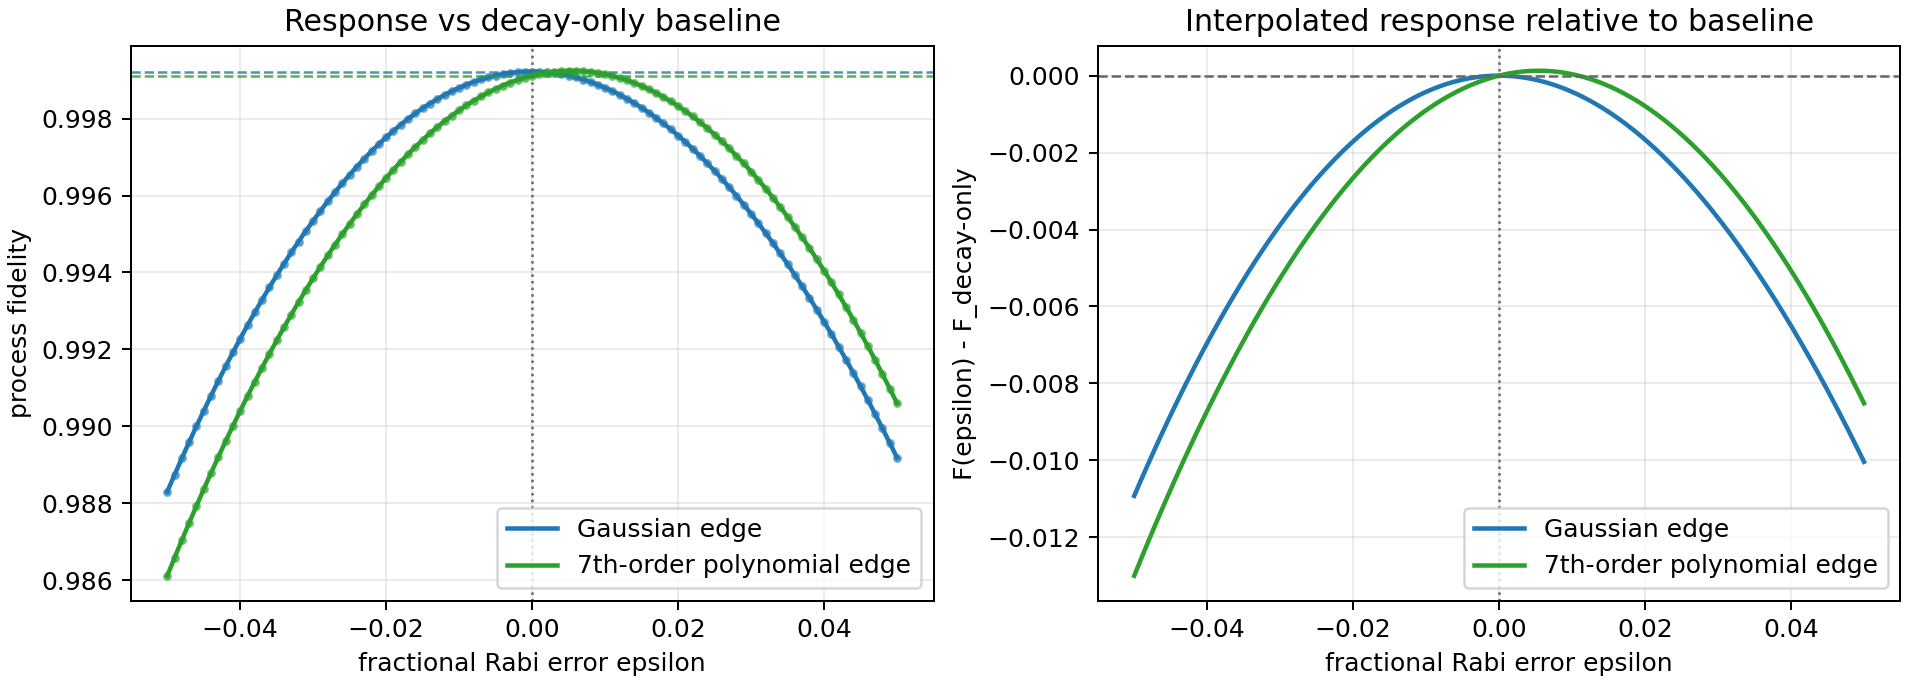

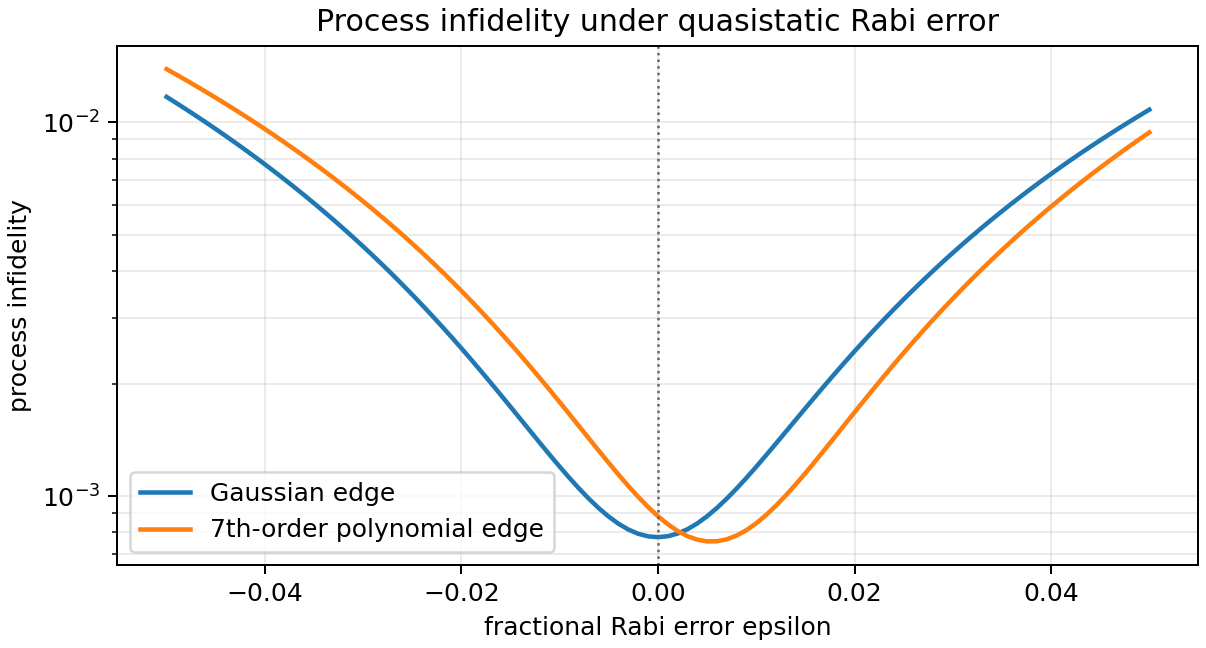

In [5]:
response_rows_by_edge = {}
for config in [GAUSSIAN_CONFIG, POLYNOMIAL_CONFIG]:
    response_rows_by_edge[config.edge_kind] = rabi_response_rows(config, selected_by_edge[config.edge_kind], EPSILON_VALUES)

all_response_rows = [row for rows in response_rows_by_edge.values() for row in rows]
response_json = ARTIFACT_DIR / "rabi_fractional_error_response.json"
response_csv = ARTIFACT_DIR / "rabi_fractional_error_response.csv"
response_json.write_text(
    json.dumps(
        {
            "config": BASE_CONFIG.__dict__,
            "epsilon_min": float(EPSILON_VALUES[0]),
            "epsilon_max": float(EPSILON_VALUES[-1]),
            "epsilon_count": int(len(EPSILON_VALUES)),
            "selected_by_edge": selected_by_edge,
            "rows": all_response_rows,
        },
        indent=2,
    ),
    encoding="utf-8",
)
with response_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(all_response_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_response_rows)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.6, 3.8), constrained_layout=True)
epsilon_dense = np.linspace(float(EPSILON_VALUES[0]), float(EPSILON_VALUES[-1]), 501)
colors = {"gaussian": "tab:blue", "polynomial_b2": "tab:green"}
labels = {"gaussian": "Gaussian edge", "polynomial_b2": "7th-order polynomial edge"}

for edge_kind, rows in response_rows_by_edge.items():
    eps = np.array([row["epsilon"] for row in rows])
    fidelity = np.array([row["process_fidelity"] for row in rows])
    delta = np.array([row["delta_from_decay_only"] for row in rows])
    fidelity_interp = PchipInterpolator(eps, fidelity)(epsilon_dense)
    delta_interp = PchipInterpolator(eps, delta)(epsilon_dense)
    baseline = float(rows[0]["decay_only_baseline_fidelity"])
    ax0.plot(eps, fidelity, "o", ms=2.6, color=colors[edge_kind], alpha=0.55)
    ax0.plot(epsilon_dense, fidelity_interp, lw=1.8, color=colors[edge_kind], label=labels[edge_kind])
    ax0.axhline(baseline, color=colors[edge_kind], ls="--", lw=1.0, alpha=0.8)
    ax1.plot(epsilon_dense, delta_interp, lw=1.8, color=colors[edge_kind], label=labels[edge_kind])

ax0.axvline(0.0, color="0.4", ls=":", lw=1.0)
ax0.set_xlabel("fractional Rabi error epsilon")
ax0.set_ylabel("process fidelity")
ax0.set_title("Response vs decay-only baseline")
ax0.grid(alpha=0.25)
ax0.legend()

ax1.axhline(0.0, color="0.4", ls="--", lw=1.0)
ax1.axvline(0.0, color="0.4", ls=":", lw=1.0)
ax1.set_xlabel("fractional Rabi error epsilon")
ax1.set_ylabel("F(epsilon) - F_decay-only")
ax1.set_title("Interpolated response relative to baseline")
ax1.grid(alpha=0.25)
ax1.legend()

response_png = ARTIFACT_DIR / "gaussian_vs_polynomial_rabi_response.png"
fig.savefig(response_png, dpi=180)
plt.close(fig)

legacy_response_png = ARTIFACT_DIR / "rabi_fractional_error_response.png"
response_png.replace(legacy_response_png)
response_png = legacy_response_png
comparison_png = ARTIFACT_DIR / "gaussian_vs_polynomial_rabi_response.png"
fig, ax = plt.subplots(figsize=(6.7, 3.6), constrained_layout=True)
for edge_kind, rows in response_rows_by_edge.items():
    eps = np.array([row["epsilon"] for row in rows])
    infid = np.array([row["process_infidelity"] for row in rows])
    ax.plot(eps, infid, lw=1.8, label=labels[edge_kind])
ax.set_yscale("log")
ax.axvline(0.0, color="0.4", ls=":", lw=1.0)
ax.set_xlabel("fractional Rabi error epsilon")
ax.set_ylabel("process infidelity")
ax.set_title("Process infidelity under quasistatic Rabi error")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.savefig(comparison_png, dpi=180)
plt.close(fig)

edge_comparison_json = ARTIFACT_DIR / "edge_comparison_results.json"
edge_comparison_json.write_text(
    json.dumps(
        {
            "epsilon_min": float(EPSILON_VALUES[0]),
            "epsilon_max": float(EPSILON_VALUES[-1]),
            "selection_kind_by_edge": selection_kind_by_edge,
            "selected_by_edge": selected_by_edge,
            "decay_only_baselines": {
                edge_kind: float(rows[0]["decay_only_baseline_fidelity"]) for edge_kind, rows in response_rows_by_edge.items()
            },
        },
        indent=2,
    ),
    encoding="utf-8",
)

for edge_kind, rows in response_rows_by_edge.items():
    zero_row = min(rows, key=lambda row: abs(row["epsilon"]))
    print(
        f"{edge_kind}: epsilon=0 F={zero_row['process_fidelity']:.9f}; "
        f"baseline={zero_row['decay_only_baseline_fidelity']:.9f}; "
        f"min F over scan={min(row['process_fidelity'] for row in rows):.9f}"
    )
print(f"Saved response JSON: {response_json}")
print(f"Saved response CSV:  {response_csv}")
print(f"Saved response plot: {response_png}")
print(f"Saved edge comparison plot: {comparison_png}")
print(f"Saved edge comparison JSON: {edge_comparison_json}")


## Selected phase traces

下图给出被用于 response scan 的 phase-only 控制。传播时使用 wrapped phase；
这里只为阅读方便画 unwrapped phase。


Saved selected phase plot: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/selected_phase_trace.png
Saved selected pulse JSON: artifacts/v5/uv_rabi_noise_timeoptimal_phase_response_20260603/selected_pulse.json


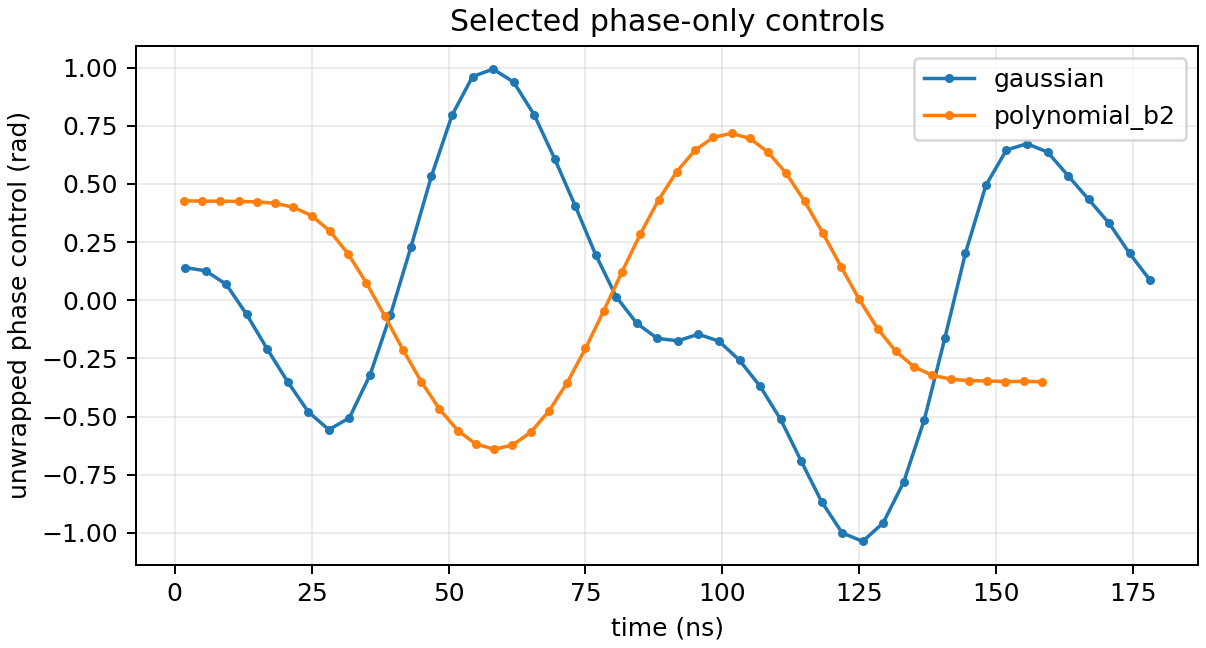

In [6]:
fig, ax = plt.subplots(figsize=(6.7, 3.6), constrained_layout=True)
for edge_kind, selected in selected_by_edge.items():
    model = UVPhaseModel(GAUSSIAN_CONFIG if edge_kind == "gaussian" else POLYNOMIAL_CONFIG, total_time_ns=float(selected["total_time_ns"]))
    phase_times_ns = (np.arange(BASE_CONFIG.num_tslots) + 0.5) * model.total_time_ns / BASE_CONFIG.num_tslots
    ax.plot(phase_times_ns, unwrap_for_plot(selected["phases"]), marker="o", ms=2.6, lw=1.4, label=edge_kind)
ax.set_xlabel("time (ns)")
ax.set_ylabel("unwrapped phase control (rad)")
ax.set_title("Selected phase-only controls")
ax.grid(alpha=0.25)
ax.legend()
phase_png = ARTIFACT_DIR / "selected_phase_trace.png"
fig.savefig(phase_png, dpi=180)
plt.close(fig)

selected_json = ARTIFACT_DIR / "selected_pulse.json"
selected_json.write_text(
    json.dumps(
        {
            "config": BASE_CONFIG.__dict__,
            "selection_kind_by_edge": selection_kind_by_edge,
            "selected_by_edge": selected_by_edge,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"Saved selected phase plot: {phase_png}")
print(f"Saved selected pulse JSON: {selected_json}")


## Validation and saved outputs

最小一致性检查包括：`epsilon=0` response 与 decay-only selected fidelity 一致；
epsilon grid 覆盖 `[-0.05, 0.05]`；Gaussian 和 polynomial edge 都产生 selected pulse。


In [7]:
for edge_kind, rows in response_rows_by_edge.items():
    zero_eps_row = min(rows, key=lambda row: abs(row["epsilon"]))
    selected = selected_by_edge[edge_kind]
    nominal_difference = abs(zero_eps_row["process_fidelity"] - selected["process_fidelity"])
    assert nominal_difference < 5e-12, (edge_kind, nominal_difference)
assert len(EPSILON_VALUES) == 101
assert abs(float(EPSILON_VALUES[0]) + 0.05) < 1e-12
assert abs(float(EPSILON_VALUES[-1]) - 0.05) < 1e-12
assert "polynomial_b2" in selected_by_edge
assert (ARTIFACT_DIR / "edge_comparison_results.json").exists()
assert np.all((polynomial_model.envelope >= 0.0) & (polynomial_model.envelope <= 1.0))

print("Validation checks passed:")
print(f"- epsilon grid covers [{EPSILON_VALUES[0]:+.2f}, {EPSILON_VALUES[-1]:+.2f}] with {len(EPSILON_VALUES)} points")
print("- epsilon=0 response matches the decay-only selected fidelity for each edge kind")
print("- Gaussian and seventh-order polynomial edge scans both produced selected pulses")
print(f"- Rydberg lifetime used in no-jump term: {BASE_CONFIG.rydberg_lifetime_s * 1e6:.1f} us")


Validation checks passed:
- epsilon grid covers [-0.05, +0.05] with 101 points
- epsilon=0 response matches the decay-only selected fidelity for each edge kind
- Gaussian and seventh-order polynomial edge scans both produced selected pulses
- Rydberg lifetime used in no-jump term: 65.0 us


## 下一步

1. 用论文 PDF 中的精确 B1/B2 公式替换当前 smoothstep placeholder。
2. 扩大 `TIME_GRID_NS`、`num_tslots` 和 optimizer starts，确认 time-optimal 相的收敛性。
3. 将 quasistatic `epsilon` 曲线扩展为指定 amplitude-noise spectrum 的 ensemble average。
